In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from PIL import Image
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch
import torchvision.models as models
from torchinfo import summary
import torch.nn as nn
import pickle
import os
import torch.nn.functional as F
import requests
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sn
import pandas as pd
import torch.optim as optim
import os
torch.manual_seed(1) # Set manual seed
from sklearn import preprocessing
from torch.utils.data import DataLoader, Dataset, Subset
from collections import Counter
# Define GPU device - We will run our model on GPU
mps_device = torch.device("mps")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split

BATCH_SIZE = 512
import torchvision.transforms as transforms

# ==========================================
# 1. BỘ TRANSFORM CHO MẠNG TỰ BUILD (32x32)
# ==========================================
train_transform_custom = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), value=1.0, inplace=False) 
])

test_transform_custom = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ==========================================
# 2. BỘ TRANSFORM CHO MẠNG PRE-TRAINED (224x224)
# ==========================================
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_transform_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20), # Ảnh to nên xoay 20 độ vô tư
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), value=1.0, inplace=False)
])

test_transform_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Dataset cho Custom
full_train_custom = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_custom)
test_set_custom   = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform_custom)

# Dataset cho Pre-trained
full_train_pre = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_pretrained)
test_set_pre   = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform_pretrained)

train_size = 40000
val_size = 10000

generator_custom = torch.Generator().manual_seed(42)
generator_pre = torch.Generator().manual_seed(42)

train_subset_custom, val_subset_custom = random_split(
    full_train_custom, [train_size, val_size], generator=generator_custom
)

train_subset_pre, val_subset_pre = random_split(
    full_train_pre, [train_size, val_size], generator=generator_pre
)

loader_train_custom = DataLoader(train_subset_custom, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
loader_val_custom   = DataLoader(val_subset_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
loader_test_custom  = DataLoader(test_set_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


loader_train_pre = DataLoader(train_subset_pre, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
loader_val_pre   = DataLoader(val_subset_pre, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
loader_test_pre  = DataLoader(test_set_pre, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

100%|██████████| 170M/170M [00:01<00:00, 99.5MB/s]


In [3]:
labels = [label for _, label in full_train_custom]

class_counts = Counter(labels)
print(class_counts)
sorted_class_counts = sorted(class_counts.items())
for digit, count in sorted_class_counts:
    print(f"Class {digit}: {count} images")

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})
Class 0: 5000 images
Class 1: 5000 images
Class 2: 5000 images
Class 3: 5000 images
Class 4: 5000 images
Class 5: 5000 images
Class 6: 5000 images
Class 7: 5000 images
Class 8: 5000 images
Class 9: 5000 images


<class 'torch.Tensor'>
<class 'torch.Tensor'>


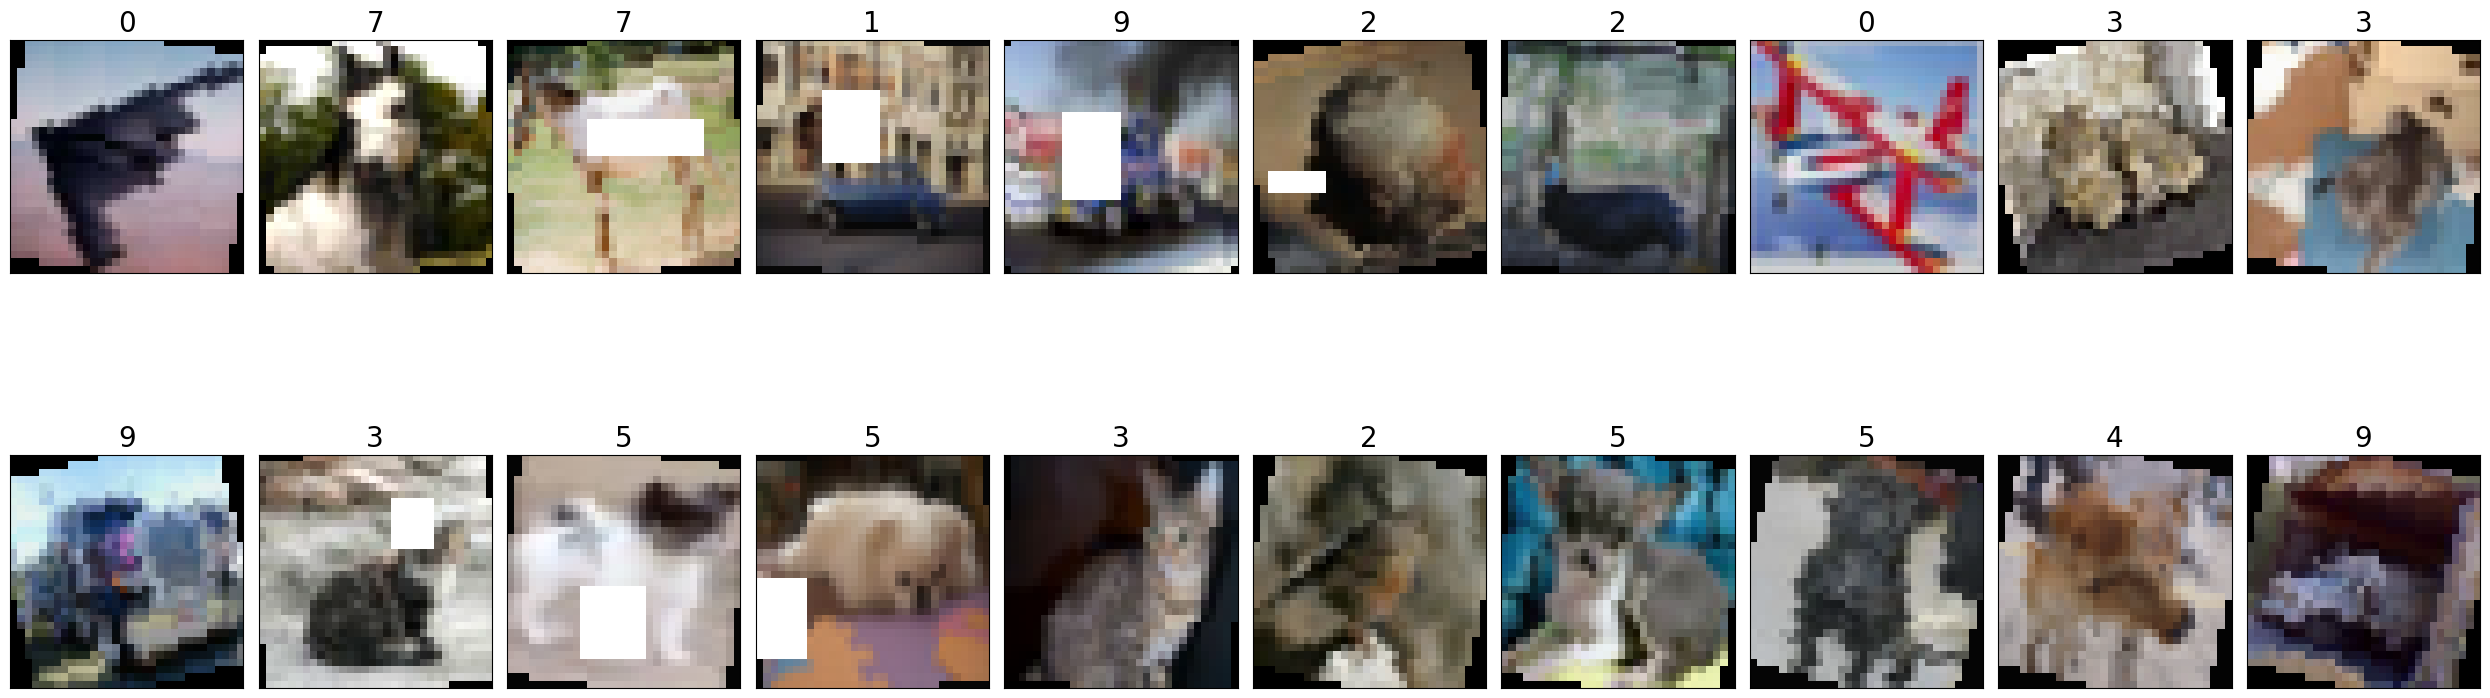

In [4]:
dataiter = iter(loader_train_custom)
images, labels = next(dataiter)
print(type(images))
print(type(labels))

images = images / 2 + 0.5
images = torch.clamp(images, 0, 1)
images = images.numpy()

fig = plt.figure(figsize = (25, 10))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks = [], yticks = [])
    image = np.transpose(images[idx], (1, 2, 0))
    ax.imshow(image)
    ax.set_title(str(labels[idx].item()), fontsize = 20)

plt.tight_layout()
plt.show()


In [5]:
def train_and_evaluate(model_name, model, train_loader, val_loader, epochs, lr, device, patience=5, save_path=None):
    print(f"\nTraining Model {model_name.upper()}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # mode='min': Theo dõi val_loss (càng nhỏ càng tốt)
    # factor=0.5: Giảm LR đi một nửa (chia 2) mỗi lần kích hoạt
    # patience=2: Waiting 2 epochs, if loss not down, decre LR
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    if save_path is None:
        save_name = model_name.replace(" ", "_").lower()
        save_path = f"best_model_{save_name}.pth"
    
    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch [{epoch+1}/{epochs}] | Current LR: {current_lr:.6f}")
        
        # --- TRAIN ---
        model.train()
        running_train_loss = 0.0
        correct_train, total_train = 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        train_loss = running_train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        
        model.eval()
        running_val_loss = 0.0
        correct_val, total_val = 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"   ↳ Train Loss: {train_loss:.4f} - Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} - Acc: {val_acc:.2f}%")
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"Save current best checkpoint")
        else:
            epochs_no_improve += 1
            print(f"Alert: Val Loss keeping ({epochs_no_improve}/{patience})")
            
            if epochs_no_improve >= patience:
                print(f"\nEARLY STOPPING! Stop at Epoch {epoch+1}.")
                break
                
    if os.path.exists(save_path):
        print(f"\nLoad model state from '{save_path}'...")
        model.load_state_dict(torch.load(save_path, map_location=device))
        
    return history

In [6]:
def evaluate_on_test(model, test_loader, device, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    test_acc = 100 * correct / total
    return test_acc

## Softmax Regression

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

class SoftmaxRegression(nn.Module):
    def __init__(self):
        super(SoftmaxRegression, self).__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=32*32*3, out_features=10)
        
    def forward(self, x):
        # Bước 1: Flatten ảnh thành vector 1D
        x = self.flatten(x)
        # Bước 2: Ánh xạ tuyến tính (Logits)
        logits = self.linear(x)
        
        # Trả về logits (việc áp dụng Softmax sẽ được CrossEntropyLoss tự động xử lý)
        return logits


model = SoftmaxRegression().to(device)

In [8]:
# CrossEntropyLoss đã bao gồm Softmax bên trong nó
criterion = nn.CrossEntropyLoss()
lr=0.001
# Sử dụng Stochastic Gradient Descent (SGD) hoặc Adam để tối ưu hóa
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

softmax_model = SoftmaxRegression().to(device)

EPOCHS = 100
LEARNING_RATE = 0.001


history_softmax = train_and_evaluate(
    model_name="Softmax Regression",
    model=softmax_model,
    train_loader=loader_train_custom,
    val_loader=loader_val_custom,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    patience=5,
    save_path="best_model_softmax.pth"
)


Training Model SOFTMAX REGRESSION

Epoch [1/100] | Current LR: 0.001000
   ↳ Train Loss: 1.9177 - Acc: 32.26% | Val Loss: 1.8420 - Acc: 35.64%
Save current best checkpoint

Epoch [2/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8469 - Acc: 35.45% | Val Loss: 1.8208 - Acc: 37.12%
Save current best checkpoint

Epoch [3/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8232 - Acc: 36.50% | Val Loss: 1.8060 - Acc: 37.37%
Save current best checkpoint

Epoch [4/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8095 - Acc: 36.90% | Val Loss: 1.8089 - Acc: 37.17%
Alert: Val Loss keeping (1/5)

Epoch [5/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8142 - Acc: 37.37% | Val Loss: 1.8160 - Acc: 37.10%
Alert: Val Loss keeping (2/5)

Epoch [6/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8057 - Acc: 37.54% | Val Loss: 1.8009 - Acc: 37.20%
Save current best checkpoint

Epoch [7/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8039 - Acc: 37.34% | Val Loss: 1.8063 - Acc: 37.63%
Alert: Val Loss keeping (1

## MLP

In [10]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        
        # Kích thước đầu vào: 3 kênh màu * 32 width * 32 height = 3072
        self.flatten = nn.Flatten()
        
        # Xây dựng các lớp ẩn (Hidden Layers)
        self.network = nn.Sequential(
            # Lớp ẩn 1: 3072 -> 512 nodes
            nn.Linear(in_features=32*32*3, out_features=512),
            nn.BatchNorm1d(512), # Chuẩn hóa dữ liệu giúp hội tụ nhanh hơn
            nn.ReLU(),
            nn.Dropout(p=0.3),   # Tắt ngẫu nhiên 30% node để chống Overfitting
            
            # Lớp ẩn 2: 512 -> 128 nodes
            nn.Linear(in_features=512, out_features=128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            # Lớp đầu ra (Output Layer): 128 -> 10 classes
            nn.Linear(in_features=128, out_features=10)
        )
        
    def forward(self, x):
        # Bước 1: Flatten ảnh thành vector 1D
        x = self.flatten(x)
        # Bước 2: Truyền qua mạng MLP
        logits = self.network(x)
        
        return logits

# Kiểm tra nhanh cấu trúc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model = MLP().to(device)
print(mlp_model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [11]:
EPOCHS = 100    
LEARNING_RATE = 0.001 

history_mlp = train_and_evaluate(
    model_name="MLP",
    model=mlp_model,
    train_loader=loader_train_custom,
    val_loader=loader_val_custom,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    patience=7,
    save_path="best_model_mlp.pth"
)


Training Model MLP

Epoch [1/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8769 - Acc: 32.38% | Val Loss: 1.7089 - Acc: 39.17%
Save current best checkpoint

Epoch [2/100] | Current LR: 0.001000
   ↳ Train Loss: 1.7147 - Acc: 38.48% | Val Loss: 1.6240 - Acc: 42.26%
Save current best checkpoint

Epoch [3/100] | Current LR: 0.001000
   ↳ Train Loss: 1.6561 - Acc: 40.72% | Val Loss: 1.5798 - Acc: 43.77%
Save current best checkpoint

Epoch [4/100] | Current LR: 0.001000
   ↳ Train Loss: 1.6166 - Acc: 41.81% | Val Loss: 1.5380 - Acc: 45.53%
Save current best checkpoint

Epoch [5/100] | Current LR: 0.001000
   ↳ Train Loss: 1.5869 - Acc: 43.35% | Val Loss: 1.5045 - Acc: 46.33%
Save current best checkpoint

Epoch [6/100] | Current LR: 0.001000
   ↳ Train Loss: 1.5655 - Acc: 44.07% | Val Loss: 1.4989 - Acc: 46.81%
Save current best checkpoint

Epoch [7/100] | Current LR: 0.001000
   ↳ Train Loss: 1.5525 - Acc: 44.34% | Val Loss: 1.4769 - Acc: 47.23%
Save current best checkpoint

Epoch [8/100]

## CNN

In [12]:
def conv3x3(channels_in, channels_out):
    """Tích chập 3x3 giữ nguyên kích thước không gian ảnh (padding=1)."""
    return nn.Conv2d(channels_in, channels_out, kernel_size=3, stride=1, padding=1, bias=False)

def strided_conv_pool(channels_in):
    """Dùng tích chập với stride=2 để giảm một nửa kích thước ảnh."""
    return nn.Conv2d(channels_in, channels_in, kernel_size=2, stride=2, bias=False)

def conv1x1(channels_in, channels_out):
    """Tích chập 1x1 dùng để thay đổi số lượng kênh (channels)."""
    return nn.Conv2d(channels_in, channels_out, kernel_size=1, stride=1)


class PreActConvLayer(nn.Sequential):
    """Lớp Pre-activation: Chuẩn hóa (BatchNorm) -> Kích hoạt (ReLU) -> Tích chập (Conv)"""
    def __init__(self, channels):
        super().__init__(
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=False), 
            conv3x3(channels, channels)
        )

class ResidualBlock(nn.Module):
    """Khối Residual với cơ chế kết nối tắt (skip connections)."""
    def __init__(self, channels, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([PreActConvLayer(channels) for _ in range(num_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x) + x 
        return x

class TransitionLayer(nn.Sequential):
    """Lớp chuyển tiếp: Đổi số kênh, giảm kích thước ảnh và dùng Dropout."""
    def __init__(self, channels_in, channels_out, dropout_rate=0.1):
        super().__init__(
            nn.BatchNorm2d(channels_in),
            nn.ReLU(inplace=False),
            conv1x1(channels_in, channels_out),
            strided_conv_pool(channels_out),
            nn.Dropout(dropout_rate)
        )

class Stage(nn.Sequential):
    """Gói gọn một giai đoạn gồm khối Residual và khối Chuyển tiếp."""
    def __init__(self, channels_in, channels_out, num_layers):
        super().__init__(
            ResidualBlock(channels_in, num_layers),
            TransitionLayer(channels_in, channels_out)
        )


class CustomResNet(nn.Sequential):
    def __init__(self):
        super().__init__(
            # Mở rộng số kênh từ 3 lên 32 ngay từ đầu
            conv3x3(channels_in=3, channels_out=32),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            # Bắt đầu các Stage với đầu vào đã là 32 kênh rộng rãi
            Stage(channels_in=32,  channels_out=64,  num_layers=5),  # Output: 64x16x16
            Stage(channels_in=64,  channels_out=128, num_layers=5),  # Output: 128x8x8
            Stage(channels_in=128, channels_out=64,  num_layers=5),  # Output: 64x4x4
            Stage(channels_in=64,  channels_out=32,  num_layers=5),  # Output: 32x2x2
            Stage(channels_in=32,  channels_out=16,  num_layers=5),  # Output: 16x1x1  
            
            conv1x1(channels_in=16, channels_out=10),                # Output: 10x1x1
            nn.Flatten()                                             # Output: 10
        )

In [13]:
LEARNING_RATE = 0.001

cnn_model = CustomResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)

cnn_model = cnn_model.to(device)

summary(cnn_model, input_size=(1, 3, 32, 32))


Layer (type:depth-idx)                        Output Shape              Param #
CustomResNet                                  [1, 10]                   --
├─Conv2d: 1-1                                 [1, 32, 32, 32]           864
├─BatchNorm2d: 1-2                            [1, 32, 32, 32]           64
├─ReLU: 1-3                                   [1, 32, 32, 32]           --
├─Stage: 1-4                                  [1, 64, 16, 16]           --
│    └─ResidualBlock: 2-1                     [1, 32, 32, 32]           --
│    │    └─ModuleList: 3-1                   --                        46,400
│    └─TransitionLayer: 2-2                   [1, 64, 16, 16]           --
│    │    └─BatchNorm2d: 3-2                  [1, 32, 32, 32]           64
│    │    └─ReLU: 3-3                         [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-4                       [1, 64, 32, 32]           2,112
│    │    └─Conv2d: 3-5                       [1, 64, 16, 16]           16,384
│    │  

In [14]:
EPOCHS = 100
history_cnn = train_and_evaluate(
    "CNN", cnn_model, 
    loader_train_custom, loader_val_custom,
    EPOCHS, lr=0.001, device=device, patience=5
)



Training Model CNN

Epoch [1/100] | Current LR: 0.001000
   ↳ Train Loss: 1.8764 - Acc: 28.68% | Val Loss: 1.7967 - Acc: 35.68%
Save current best checkpoint

Epoch [2/100] | Current LR: 0.001000
   ↳ Train Loss: 1.4970 - Acc: 44.92% | Val Loss: 1.5982 - Acc: 42.98%
Save current best checkpoint

Epoch [3/100] | Current LR: 0.001000
   ↳ Train Loss: 1.3021 - Acc: 53.09% | Val Loss: 1.2183 - Acc: 56.08%
Save current best checkpoint

Epoch [4/100] | Current LR: 0.001000
   ↳ Train Loss: 1.1661 - Acc: 58.50% | Val Loss: 1.1649 - Acc: 58.73%
Save current best checkpoint

Epoch [5/100] | Current LR: 0.001000
   ↳ Train Loss: 1.0648 - Acc: 62.40% | Val Loss: 1.3479 - Acc: 54.88%
Alert: Val Loss keeping (1/5)

Epoch [6/100] | Current LR: 0.001000
   ↳ Train Loss: 0.9739 - Acc: 65.96% | Val Loss: 1.0501 - Acc: 64.92%
Save current best checkpoint

Epoch [7/100] | Current LR: 0.001000
   ↳ Train Loss: 0.9063 - Acc: 68.50% | Val Loss: 1.0027 - Acc: 65.26%
Save current best checkpoint

Epoch [8/100

## ViT

In [15]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """Bước 1: Chia ảnh thành các patch và chuyển thành chuỗi vector (Sequence of Patches)"""
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        
        # Mẹo thực chiến: Dùng Conv2d với kernel_size và stride bằng patch_size 
        # là cách nhanh nhất và tối ưu hóa bộ nhớ nhất để cắt patch và ánh xạ tuyến tính.
        self.proj = nn.Conv2d(
            in_channels, embed_dim, 
            kernel_size=patch_size, stride=patch_size
        )
        
        # Số lượng patch: (32 / 4) * (32 / 4) = 8 * 8 = 64 patches
        self.num_patches = (img_size // patch_size) ** 2

    def forward(self, x):
        # x input: (Batch, Channels, Height, Width)
        x = self.proj(x)                  # Output: (Batch, embed_dim, H/P, W/P)
        x = x.flatten(2)                  # Output: (Batch, embed_dim, Num_Patches)
        x = x.transpose(1, 2)             # Output: (Batch, Num_Patches, embed_dim) - Dạng Sequence chuẩn
        return x

class SimpleViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10, 
                 embed_dim=128, depth=4, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim, img_size)
        
        # 2. Class Token & Positional Encoding
        # Class token là một vector học được, dùng để đại diện cho toàn bộ bức ảnh
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional encoding để báo cho mô hình biết vị trí của từng patch (vì Transformer không hiểu thứ tự)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)
        
        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        # Ghép nhiều lớp Encoder lại với nhau theo tham số `depth`
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        # 4. Classification Head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        
        # --- Bước 1: Patch Embedding ---
        x = self.patch_embed(x) # (Batch, N, embed_dim)
        
        # --- Bước 2: Nối Class Token vào đầu chuỗi ---
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) # (Batch, N+1, embed_dim)
        
        # --- Bước 3: Cộng Positional Encoding ---
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        # --- Bước 4: Truyền qua Transformer Encoder ---
        x = self.transformer_encoder(x)
        
        # --- Bước 5: Phân loại ---
        # Chỉ lấy vector ở vị trí đầu tiên (tương ứng với Class Token) để phân loại
        cls_output = x[:, 0]
        cls_output = self.norm(cls_output)
        logits = self.head(cls_output)
        
        return logits

In [16]:
vit_model = SimpleViT(
    img_size=32, patch_size=4, 
    embed_dim=128, depth=6, num_heads=8
).to(device)

EPOCHS = 100
LEARNING_RATE = 0.0003

history_vit = train_and_evaluate(
    model_name="Simple ViT",
    model=vit_model,
    train_loader=loader_train_custom,
    val_loader=loader_val_custom,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    patience=10,
    save_path="best_model_vit.pth"
)


Training Model SIMPLE VIT

Epoch [1/100] | Current LR: 0.000300


/tmp/ipykernel_24/3464181048.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


   ↳ Train Loss: 1.9547 - Acc: 27.31% | Val Loss: 1.8244 - Acc: 31.41%
Save current best checkpoint

Epoch [2/100] | Current LR: 0.000300
   ↳ Train Loss: 1.7600 - Acc: 34.34% | Val Loss: 1.7036 - Acc: 37.13%
Save current best checkpoint

Epoch [3/100] | Current LR: 0.000300
   ↳ Train Loss: 1.6484 - Acc: 38.64% | Val Loss: 1.6080 - Acc: 41.63%
Save current best checkpoint

Epoch [4/100] | Current LR: 0.000300
   ↳ Train Loss: 1.5452 - Acc: 43.12% | Val Loss: 1.4754 - Acc: 45.88%
Save current best checkpoint

Epoch [5/100] | Current LR: 0.000300
   ↳ Train Loss: 1.4566 - Acc: 46.74% | Val Loss: 1.4084 - Acc: 49.12%
Save current best checkpoint

Epoch [6/100] | Current LR: 0.000300
   ↳ Train Loss: 1.3876 - Acc: 49.50% | Val Loss: 1.3600 - Acc: 50.15%
Save current best checkpoint

Epoch [7/100] | Current LR: 0.000300
   ↳ Train Loss: 1.3320 - Acc: 51.56% | Val Loss: 1.2691 - Acc: 53.87%
Save current best checkpoint

Epoch [8/100] | Current LR: 0.000300
   ↳ Train Loss: 1.2926 - Acc: 53.

## Tự hiện thực TransformerEncoder và ViT

In [17]:
import torch
import torch.nn as nn

class CustomMHSA(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == embed_dim, "embed_dim phải chia hết cho num_heads"
        
        self.scale = self.head_dim ** -0.5

        # Tính Q, K, V cùng lúc để tối ưu tốc độ
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        
        # 1. Tính Q, K, V
        # Đầu ra của qkv(x): (Batch, SeqLen, 3 * embed_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4) # (3, B, num_heads, SeqLen, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2] 
        
        # 2. Tính Attention Scores (Q * K^T) bằng einsum
        # Ký hiệu: b (batch), h (heads), i (query_seq_len), j (key_seq_len), d (head_dim)
        attn_scores = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale
        
        # 3. Softmax để ra Attention Weights
        attn = attn_scores.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        # 4. Nhân với V (Attention * V) bằng einsum
        out = torch.einsum('bhij,bhjd->bhid', attn, v)
        
        # 5. Gộp các heads lại và chiếu qua lớp Linear cuối
        out = out.transpose(1, 2).reshape(B, N, C) # (B, SeqLen, embed_dim)
        out = self.proj(out)
        out = self.proj_drop(out)
        
        return out

class CustomMLP(nn.Module):
    """Mạng Feed-Forward bên trong Transformer Block"""
    def __init__(self, in_features, hidden_features, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [18]:
class CustomTransformerBlock(nn.Module):
    """Thay thế hoàn toàn cho nn.TransformerEncoderLayer"""
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = CustomMHSA(embed_dim, num_heads, dropout)
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = CustomMLP(embed_dim, int(embed_dim * mlp_ratio), dropout)

    def forward(self, x):
        # Kiến trúc Pre-LN với Residual Connection
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class CustomViT(nn.Module):
    """Mô hình ViT sử dụng khối Transformer tự code"""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10, 
                 embed_dim=128, depth=6, num_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        # Tái sử dụng PatchEmbedding từ Phần 1 (giả sử bạn đã có class này)
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim, img_size)
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)
        
        # Sử dụng nn.ModuleList chứa các khối CustomTransformerBlock thay vì nn.TransformerEncoder
        self.blocks = nn.ModuleList([
            CustomTransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        # Chạy qua từng lớp Transformer tự build
        for block in self.blocks:
            x = block(x)
            
        cls_output = self.norm(x[:, 0])
        logits = self.head(cls_output)
        return logits

In [19]:
custom_vit_model = CustomViT(
    img_size=32, patch_size=4, 
    embed_dim=128, depth=6, num_heads=8
).to(device)

EPOCHS = 100
LEARNING_RATE = 0.0003 # ViT từ đầu (from scratch) thường cần LR lớn hơn kèm optimizer tốt (như AdamW)

# Nếu dùng ViT, khuyến nghị dùng AdamW thay vì Adam thường để kiểm soát weight decay tốt hơn. 
# Tuy nhiên, để nhất quán với hàm train_and_evaluate của bạn (đang dùng Adam bên trong), ta cứ gọi hàm:

history_custom_vit = train_and_evaluate(
    model_name="Custom ViT",
    model=custom_vit_model,
    train_loader=loader_train_custom,
    val_loader=loader_val_custom,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    patience=10, # Chờ lâu hơn vì ViT hội tụ chậm ở giai đoạn đầu
    save_path="best_model_custom_vit.pth"
)


Training Model CUSTOM VIT

Epoch [1/100] | Current LR: 0.000300
   ↳ Train Loss: 1.9661 - Acc: 26.64% | Val Loss: 1.8307 - Acc: 31.85%
Save current best checkpoint

Epoch [2/100] | Current LR: 0.000300
   ↳ Train Loss: 1.7698 - Acc: 33.62% | Val Loss: 1.6950 - Acc: 37.23%
Save current best checkpoint

Epoch [3/100] | Current LR: 0.000300
   ↳ Train Loss: 1.6523 - Acc: 38.25% | Val Loss: 1.5957 - Acc: 41.00%
Save current best checkpoint

Epoch [4/100] | Current LR: 0.000300
   ↳ Train Loss: 1.5634 - Acc: 42.07% | Val Loss: 1.6262 - Acc: 38.63%
Alert: Val Loss keeping (1/10)

Epoch [5/100] | Current LR: 0.000300
   ↳ Train Loss: 1.4837 - Acc: 45.72% | Val Loss: 1.4079 - Acc: 48.91%
Save current best checkpoint

Epoch [6/100] | Current LR: 0.000300
   ↳ Train Loss: 1.3964 - Acc: 49.18% | Val Loss: 1.3788 - Acc: 50.55%
Save current best checkpoint

Epoch [7/100] | Current LR: 0.000300
   ↳ Train Loss: 1.3437 - Acc: 51.42% | Val Loss: 1.3032 - Acc: 52.85%
Save current best checkpoint

Epoc

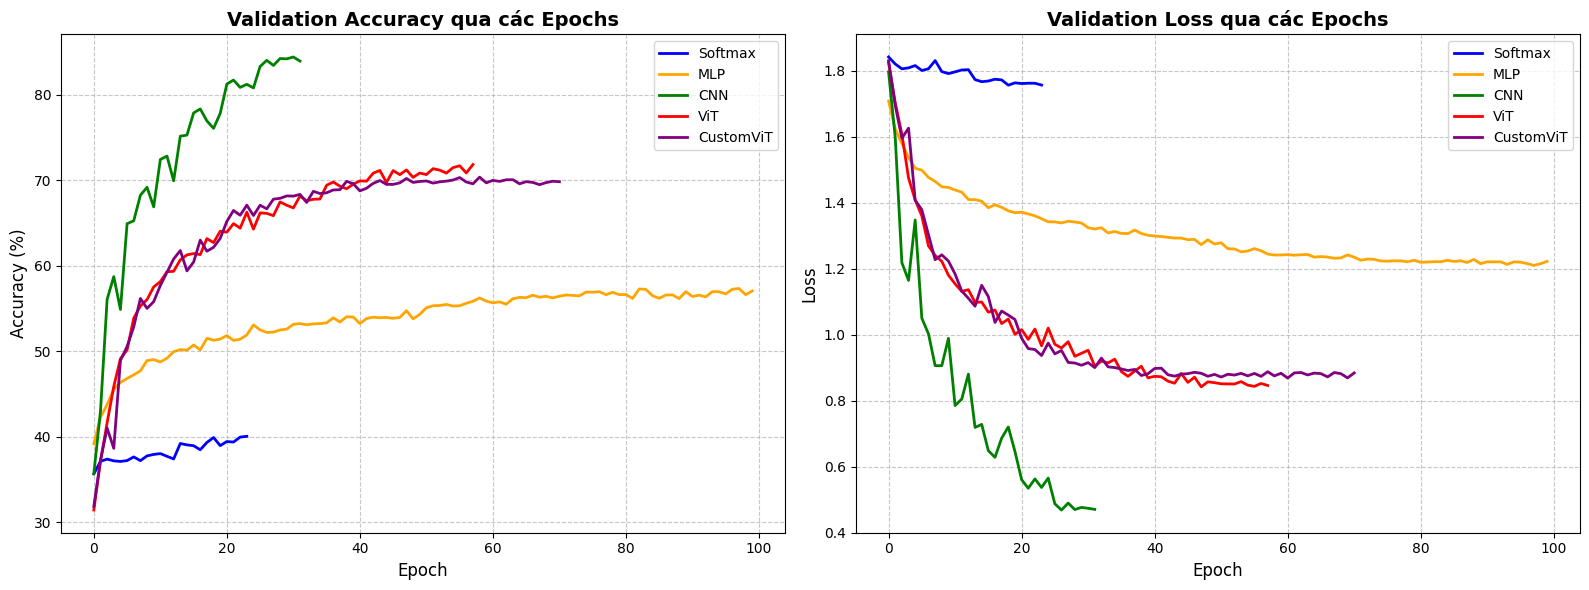

In [20]:
import matplotlib.pyplot as plt

def plot_model_comparisons(histories_dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'gray']
    
    # Vẽ Validation Accuracy
    for (model_name, history), color in zip(histories_dict.items(), colors):
        ax1.plot(history['val_acc'], label=f'{model_name}', color=color, linewidth=2)
    ax1.set_title('Validation Accuracy qua các Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy (%)', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Vẽ Validation Loss
    for (model_name, history), color in zip(histories_dict.items(), colors):
        ax2.plot(history['val_loss'], label=f'{model_name}', color=color, linewidth=2)
    ax2.set_title('Validation Loss qua các Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Cách gọi hàm (bạn tự thay bằng history thật của bạn khi chạy xong):
histories = {
    'Softmax': history_softmax,
    'MLP': history_mlp,
    'CNN': history_cnn,
    'ViT': history_vit,
    'CustomViT': history_custom_vit
}

plot_model_comparisons(histories)

## Cách 1: Mô hình Lai (CNN + Transformer) – Biến không gian H×W thành Token

In [21]:
import torch
import torch.nn as nn

class CNNBackbone(nn.Module):
    """Trích xuất đặc trưng cục bộ, giảm kích thước ảnh."""
    def __init__(self, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # 32x32 -> 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, embed_dim, kernel_size=3, stride=2, padding=1), # 16x16 -> 8x8
            nn.BatchNorm2d(embed_dim),
            nn.ReLU()
        )
        # Số lượng token sẽ là 8 * 8 = 64 tokens

    def forward(self, x):
        return self.net(x)

class HybridCNNTransformer(nn.Module):
    def __init__(self, embed_dim=128, num_classes=10, depth=4, num_heads=4):
        super().__init__()
        self.cnn = CNNBackbone(embed_dim)
        
        # Số token = H' * W' = 8 * 8 = 64
        self.num_patches = 64 
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=embed_dim*4, dropout=0.1, 
            activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        
        # 1. Trích xuất đặc trưng bằng CNN
        x = self.cnn(x) # (Batch, embed_dim, 8, 8)
        
        # 2. Biến không gian H x W thành các sequence tokens
        x = x.flatten(2) # (Batch, embed_dim, 64)
        x = x.transpose(1, 2) # (Batch, 64, embed_dim) -> Dạng chuẩn Sequence
        
        # 3. Nối Class Token và Positional Encoding
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) # (Batch, 65, embed_dim)
        x = x + self.pos_embed
        
        # 4. Đưa qua Transformer và Phân loại
        x = self.transformer(x)
        cls_output = self.norm(x[:, 0])
        return self.head(cls_output)

## Cách 2: Tokenizer với Overlapping Patches (Patch chồng mép)

In [22]:
class OverlappingPatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, img_size=32):
        super().__init__()
        # Thay vì kernel=4, stride=4 (non-overlap)
        # Ta dùng kernel=7, stride=2, padding=3 (overlap)
        # Kích thước đầu ra: (32 + 2*3 - 7)//2 + 1 = 16. (16x16 = 256 patches)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=7, stride=2, padding=3)
        self.num_patches = 16 * 16

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class OverlappingViT(nn.Module):
    def __init__(self, embed_dim=128, num_classes=10, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = OverlappingPatchEmbedding(embed_dim=embed_dim)
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=embed_dim*4, dropout=0.1, 
            activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        
        x = self.transformer(x)
        cls_output = self.norm(x[:, 0])
        return self.head(cls_output)

In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang huấn luyện trên thiết bị: {device}")

hybrid_model = HybridCNNTransformer(embed_dim=128, num_classes=10, depth=4, num_heads=4).to(device)
overlap_vit_model = OverlappingViT(embed_dim=128, num_classes=10, depth=4, num_heads=4).to(device)

EPOCHS = 100
LEARNING_RATE = 0.0003

# =====================================================================
# HUẤN LUYỆN MÔ HÌNH 1: HYBRID CNN + TRANSFORMER
# =====================================================================
print("\n" + "="*50)
print("BẮT ĐẦU HUẤN LUYỆN: HYBRID CNN-TRANSFORMER")
print("="*50)

history_hybrid = train_and_evaluate(
    model_name="Hybrid CNN_ViT",
    model=hybrid_model,
    train_loader=loader_train_custom,
    val_loader=loader_val_custom,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    patience=7,
    save_path="best_model_hybrid.pth"
)

# =====================================================================
# HUẤN LUYỆN MÔ HÌNH 2: OVERLAPPING ViT
# =====================================================================
print("\n" + "="*50)
print("BẮT ĐẦU HUẤN LUYỆN: OVERLAPPING ViT")
print("="*50)

history_overlap = train_and_evaluate(
    model_name="Overlapping ViT",
    model=overlap_vit_model,
    train_loader=loader_train_custom,
    val_loader=loader_val_custom,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    patience=7,
    save_path="best_model_overlap_vit.pth"
)

# =====================================================================
# ĐÁNH GIÁ TRÊN TẬP TEST (TEST SET)
# =====================================================================
print("\n" + "="*50)
print("KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST")
print("="*50)

acc_test_hybrid = evaluate_on_test(hybrid_model, loader_test_custom, device, "best_model_hybrid.pth")
acc_test_overlap = evaluate_on_test(overlap_vit_model, loader_test_custom, device, "best_model_overlap_vit.pth")

print(f"Accuracy của Hybrid CNN-Transformer: {acc_test_hybrid:.2f}%")
print(f"Accuracy của Overlapping ViT:       {acc_test_overlap:.2f}%")

Đang huấn luyện trên thiết bị: cuda

BẮT ĐẦU HUẤN LUYỆN: HYBRID CNN-TRANSFORMER

Training Model HYBRID CNN_VIT

Epoch [1/100] | Current LR: 0.000300


/tmp/ipykernel_24/1058060958.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_24/3062069686.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


   ↳ Train Loss: 1.8056 - Acc: 33.02% | Val Loss: 1.6388 - Acc: 40.49%
Save current best checkpoint

Epoch [2/100] | Current LR: 0.000300
   ↳ Train Loss: 1.5796 - Acc: 41.95% | Val Loss: 1.5123 - Acc: 44.79%
Save current best checkpoint

Epoch [3/100] | Current LR: 0.000300
   ↳ Train Loss: 1.4805 - Acc: 46.02% | Val Loss: 1.4322 - Acc: 47.92%
Save current best checkpoint

Epoch [4/100] | Current LR: 0.000300
   ↳ Train Loss: 1.4112 - Acc: 48.37% | Val Loss: 1.4649 - Acc: 46.70%
Alert: Val Loss keeping (1/7)

Epoch [5/100] | Current LR: 0.000300
   ↳ Train Loss: 1.3635 - Acc: 50.45% | Val Loss: 1.3677 - Acc: 50.62%
Save current best checkpoint

Epoch [6/100] | Current LR: 0.000300
   ↳ Train Loss: 1.3149 - Acc: 52.61% | Val Loss: 1.2938 - Acc: 53.69%
Save current best checkpoint

Epoch [7/100] | Current LR: 0.000300
   ↳ Train Loss: 1.2718 - Acc: 53.86% | Val Loss: 1.2844 - Acc: 53.85%
Save current best checkpoint

Epoch [8/100] | Current LR: 0.000300
   ↳ Train Loss: 1.2477 - Acc: 54

MÔ HÌNH                   | TEST ACCURACY (%)   
Softmax                   |           40.89%
MLP                       |           58.91%
CNN (CustomResNet)        |           86.20%
ViT (PyTorch API)         |           72.52%
Hybrid CNN-ViT            |           74.81%
Overlapping ViT           |           74.01%


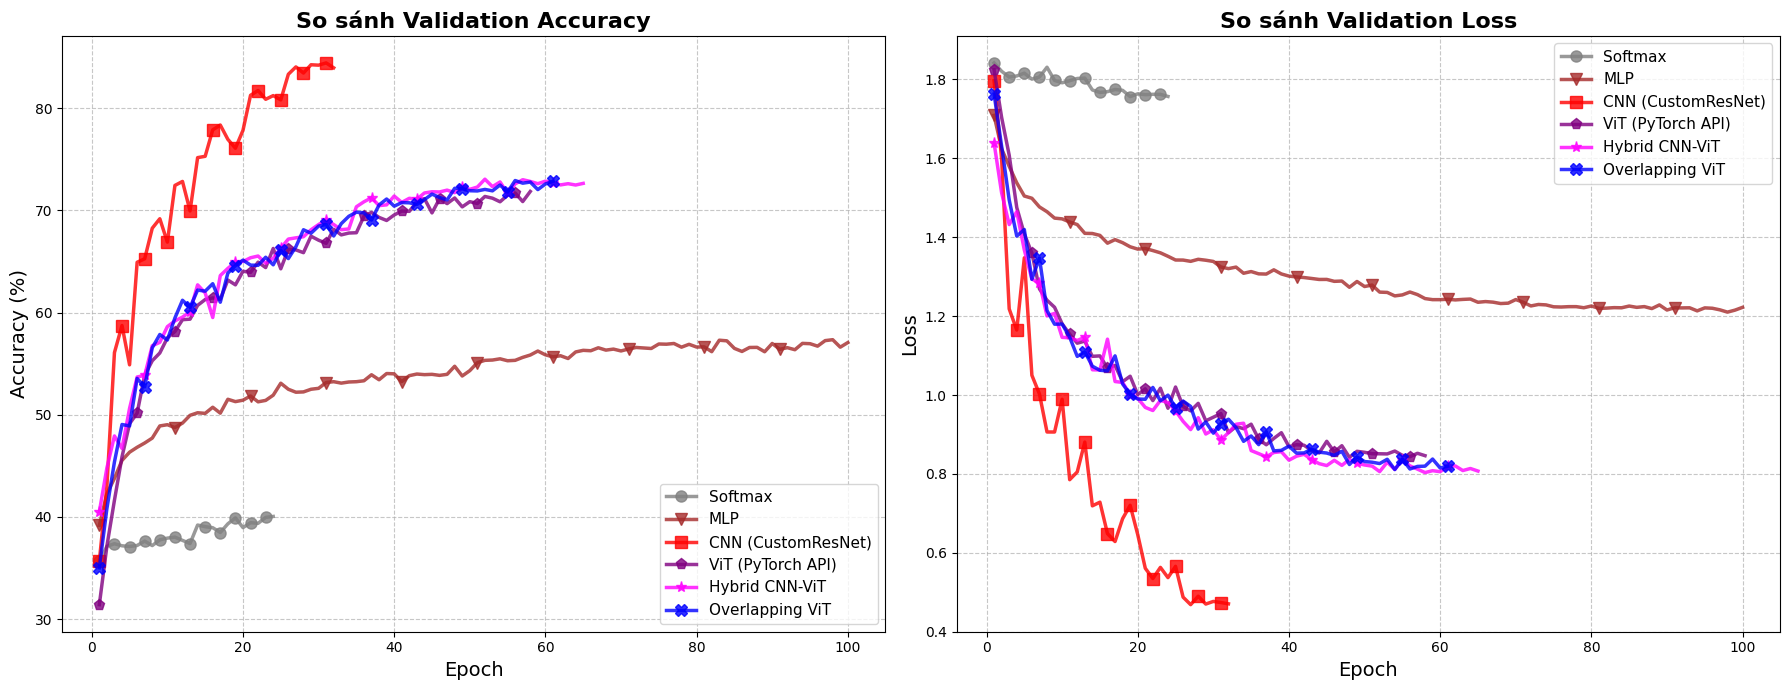

In [24]:
import torch
import matplotlib.pyplot as plt

all_histories = {
    "Softmax": history_softmax,
    "MLP": history_mlp,
    "CNN (CustomResNet)": history_cnn,
    "ViT (PyTorch API)": history_vit,
    "Hybrid CNN-ViT": history_hybrid,
    "Overlapping ViT": history_overlap
}

all_models_checkpoints = {
    "Softmax": (softmax_model, "best_model_softmax.pth"),
    "MLP": (mlp_model, "best_model_mlp.pth"),
    "CNN (CustomResNet)": (cnn_model, "best_model_cnn.pth"),
    "ViT (PyTorch API)": (vit_model, "best_model_vit.pth"),
    "Hybrid CNN-ViT": (hybrid_model, "best_model_hybrid.pth"),
    "Overlapping ViT": (overlap_vit_model, "best_model_overlap_vit.pth")
}

# ==========================================
# 2. IN BẢNG TEST ACCURACY
# ==========================================
print("="*60)
print(f"{'MÔ HÌNH':<25} | {'TEST ACCURACY (%)':<20}")
print("="*60)

test_results = {}
for model_name, (model_instance, ckpt_path) in all_models_checkpoints.items():
    try:
        acc = evaluate_on_test(model_instance, loader_test_custom, device, ckpt_path)
        test_results[model_name] = acc
        print(f"{model_name:<25} | {acc:>15.2f}%")
    except Exception as e:
        print(f"{model_name:<25} | {'CHƯA TRAIN / LỖI':>15}")

print("="*60)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = ['gray', 'brown', 'red', 'purple', 'magenta', 'blue', 'orange']
markers = ['o', 'v', 's', 'p', '*', 'X', 'D']

for (model_name, history), color, marker in zip(all_histories.items(), colors, markers):
    val_acc = history['val_acc']
    val_loss = history['val_loss']
    epochs_range = range(1, len(val_acc) + 1)
    mark_step = max(1, len(val_acc) // 10)
    ax1.plot(epochs_range, val_acc, label=model_name, color=color, 
             linewidth=2.5, marker=marker, markevery=mark_step, markersize=8, alpha=0.8)
    ax2.plot(epochs_range, val_loss, label=model_name, color=color, 
             linewidth=2.5, marker=marker, markevery=mark_step, markersize=8, alpha=0.8)

ax1.set_title('So sánh Validation Accuracy', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=14)
ax1.set_ylabel('Accuracy (%)', fontsize=14)
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.set_title('So sánh Validation Loss', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=14)
ax2.set_ylabel('Loss', fontsize=14)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

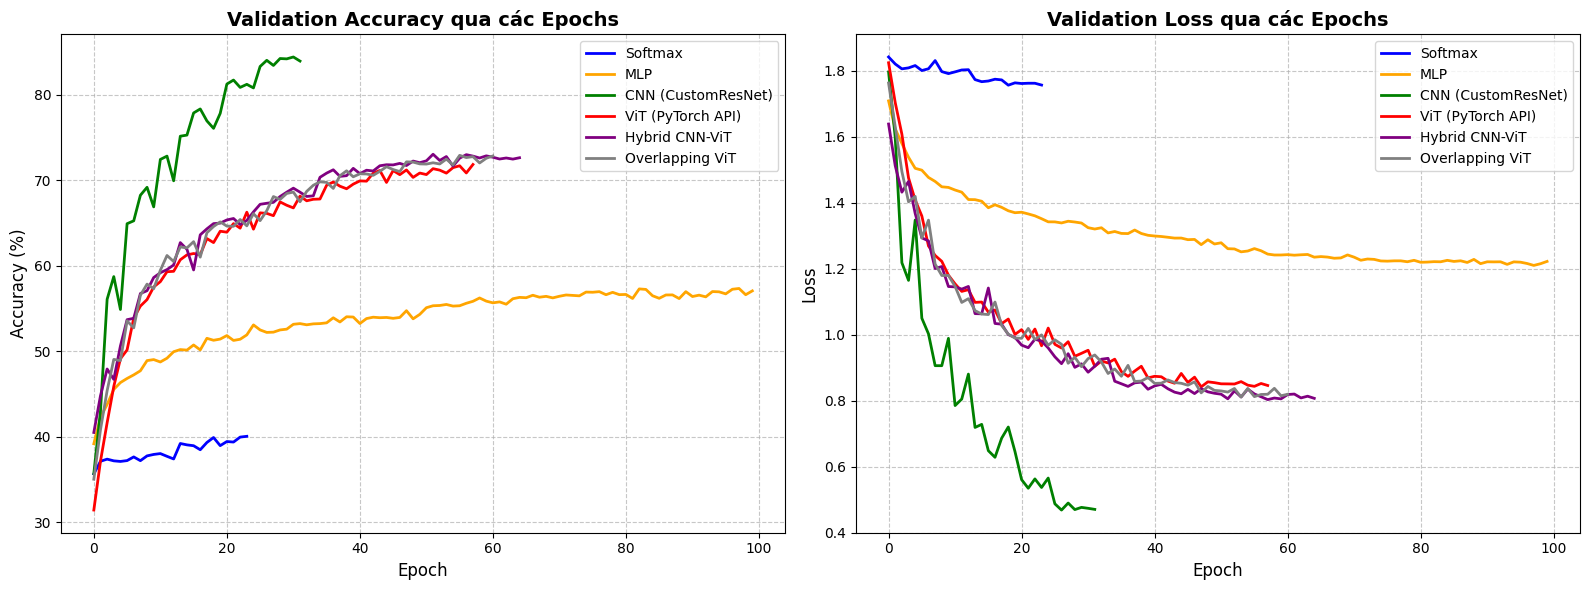

In [25]:
plot_model_comparisons(all_histories)